# Эксперимент 14: Расширенная разморозка backbone (блоки 6–11)

**Гипотеза:** В Эксп.10 разморожены только 4 последних блока (8–11). Размораживание ещё двух блоков (6–7) позволит backbone адаптироваться к специфике стальных текстур на более глубоком уровне и даст прирост на редких классах 1 и 2.

**Что изменилось относительно Эксп.10:**
- `N_UNFREEZE = 6` — разморожены блоки 6–11 вместо 8–11
- `LR_BACKBONE = 5e-6` — вдвое меньше, чтобы не разрушить низкоуровневые признаки в блоках 6–7
- Всё остальное (синтетика, аугментации, DPT-голова) идентично Эксп.10

| | Эксп.9 | Эксп.10 | Эксп.12 | **Эксп.14** |
|---|---|---|---|---|
| Backbone | Разморожен (4 блока) | Разморожен (4 блока) | Разморожен (4 блока) | **Разморожен (6 блоков)** |
| Синтетика | Нет | Да (кл.1+2) | Да (кл.1+2) | **Да (кл.1+2)** |
| LR backbone | 1e-5 | 1e-5 | 1e-5 | **5e-6** |
| Обуч. пар. | 28.4М | 28.4М | 28.4М | **~42М** |
| Декодер | DPT 2.8М | DPT 2.8М | DPT 2.8М | **DPT 2.8М** |

## 1. Импорты и конфигурация

In [1]:
import os, random, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tqdm import tqdm
from collections import Counter
from scipy.ndimage import gaussian_filter
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchmetrics import JaccardIndex
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

print(f'PyTorch: {torch.__version__}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} Гб')

DATA_DIR      = 'C:/Users/ADMIN/Desktop/magistr/VKR/steel_defect/'
TRAIN_CSV     = os.path.join(DATA_DIR, 'train.csv')
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train_images/')
save_dir      = 'C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads'
os.makedirs(save_dir, exist_ok=True)

IMG_H       = 224
IMG_W       = 1400
PATCH_SIZE  = 14
PATCH_H     = IMG_H // PATCH_SIZE   # 16
PATCH_W     = IMG_W // PATCH_SIZE   # 100
MASK_H      = PATCH_H * 4          # 64
MASK_W      = PATCH_W * 4          # 400
EMBED_DIM   = 768
NUM_CLASSES = 5

INTERMEDIATE_LAYERS = [3, 5, 8, 11]

N_UNFREEZE   = 6       # было 4 в Эксп.10 → разморозка блоков 6-11
LR_BACKBONE  = 5e-6   # было 1e-5 → снижен вдвое для защиты блоков 6-7
LR_HEAD      = 1e-3
BATCH_SIZE   = 2
EPOCHS       = 75
N_SELECT     = 200
TEST_SIZE    = 0.2
SYNTH_WEIGHT = 0.5

FLIP_P      = 0.5
CROP_SCALE  = (0.85, 1.0)
BRIGHTNESS  = 0.3

print(f'\nВход:              {IMG_H}x{IMG_W}')
print(f'Слои DPT:          {INTERMEDIATE_LAYERS}')
print(f'Разморожено блоков: {N_UNFREEZE} (блоки {12-N_UNFREEZE}-11)')
print(f'LR backbone/head:  {LR_BACKBONE} / {LR_HEAD}')
print(f'Batch size:        {BATCH_SIZE}')
print(f'Synth loss weight: {SYNTH_WEIGHT}')

PyTorch: 2.12.0.dev20260408+cu128
Устройство: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
VRAM: 8.5 Гб

Вход:              224x1400
Слои DPT:          [3, 5, 8, 11]
Разморожено блоков: 6 (блоки 6-11)
LR backbone/head:  5e-06 / 0.001
Batch size:        2
Synth loss weight: 0.5


## 2. Данные и вспомогательные функции

In [2]:
train_df    = pd.read_csv(TRAIN_CSV)
labeled_ids = train_df['ImageId'].unique().tolist()
print(f'Строк: {len(train_df):,}  |  Изображений: {len(labeled_ids):,}')


def decode_rle(rle_string, shape=(256, 1600)):
    if pd.isna(rle_string) or not isinstance(rle_string, str):
        return np.zeros(shape, dtype=np.uint8)
    nums   = list(map(int, rle_string.strip().split()))
    starts = np.array(nums[0::2]) - 1
    lens   = np.array(nums[1::2])
    mask   = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    for s, l in zip(starts, lens):
        mask[s:s+l] = 1
    return mask.reshape(shape, order='F')


def build_segmask(image_id, df, shape=(256, 1600)):
    mask = np.zeros(shape, dtype=np.uint8)
    for _, row in df[df['ImageId'] == image_id].iterrows():
        cls = int(row['ClassId'])
        m   = decode_rle(row['EncodedPixels'], shape)
        mask[m == 1] = cls
    return mask


def get_classes(img_id, df):
    rows = df[df['ImageId'] == img_id]
    return sorted(rows['ClassId'].dropna().astype(int).unique().tolist())


def compute_class_weights(image_ids, df, num_classes=NUM_CLASSES):
    px = Counter({c: 0 for c in range(num_classes)})
    for img_id in image_ids:
        mask = build_segmask(img_id, df)
        for c in range(num_classes):
            px[c] += int((mask == c).sum())
    total = sum(px.values())
    w = torch.tensor([total/(num_classes*(px[c]+1e-6)) for c in range(num_classes)])
    w = (w / w.mean()).clamp(min=0.1, max=5.0)
    print('Веса классов:')
    for c, v in enumerate(w):
        print(f'  {"Фон" if c==0 else f"Дефект {c}"}: {v:.3f}  ({px[c]:,} пикс.)')
    return w.to(DEVICE)


print('Функции определены.')

Строк: 7,095  |  Изображений: 6,666
Функции определены.


## 3. Dataset (с поддержкой синтетики)

In [3]:
class JointTransform:
    def __init__(self, img_h=IMG_H, img_w=IMG_W, is_train=True,
                 flip_p=FLIP_P, crop_scale=CROP_SCALE, brightness=BRIGHTNESS):
        self.img_h        = img_h
        self.img_w        = img_w
        self.is_train     = is_train
        self.flip_p       = flip_p
        self.crop_scale   = crop_scale
        self.color_jitter = transforms.ColorJitter(brightness=brightness)
        self.to_tensor    = transforms.ToTensor()
        self.normalize    = transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __call__(self, img_pil, mask_np):
        img_pil  = img_pil.resize((self.img_w, self.img_h), Image.BILINEAR)
        mask_pil = Image.fromarray(mask_np).resize(
            (self.img_w, self.img_h), Image.NEAREST)
        if self.is_train:
            if random.random() < self.flip_p:
                img_pil  = img_pil.transpose(Image.FLIP_LEFT_RIGHT)
                mask_pil = mask_pil.transpose(Image.FLIP_LEFT_RIGHT)
            scale  = random.uniform(*self.crop_scale)
            crop_h = max(1, int(self.img_h * scale))
            crop_w = max(1, int(self.img_w * scale))
            top    = random.randint(0, self.img_h - crop_h)
            left   = random.randint(0, self.img_w - crop_w)
            img_pil  = img_pil.crop((left, top, left+crop_w, top+crop_h))
            mask_pil = mask_pil.crop((left, top, left+crop_w, top+crop_h))
            img_pil  = img_pil.resize((self.img_w, self.img_h), Image.BILINEAR)
            mask_pil = mask_pil.resize((self.img_w, self.img_h), Image.NEAREST)
            img_pil  = self.color_jitter(img_pil)
        img_t    = self.normalize(self.to_tensor(img_pil))
        mask_np2 = np.array(mask_pil, dtype=np.uint8)
        return img_t, mask_np2


train_jt = JointTransform(is_train=True)
val_jt   = JointTransform(is_train=False)


class SteelSegDataset(Dataset):
    def __init__(self, ids, img_dir, df, joint_transform):
        self.ids=ids; self.img_dir=img_dir
        self.df=df; self.jt=joint_transform
    def __len__(self): return len(self.ids)
    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img    = Image.open(os.path.join(self.img_dir, img_id)).convert('RGB')
        mask   = build_segmask(img_id, self.df)
        img_t, mask_np = self.jt(img, mask)
        mask_t = torch.from_numpy(mask_np).unsqueeze(0).float()
        mask_t = F.interpolate(
            mask_t.unsqueeze(0), size=(MASK_H, MASK_W),
            mode='nearest').squeeze().long()
        return img_t, mask_t, 0


class SteelSegDatasetWithSynth(Dataset):
    def __init__(self, real_ids, img_dir, df, joint_transform, synth_pairs):
        self.real_ids = real_ids
        self.img_dir  = img_dir
        self.df       = df
        self.jt       = joint_transform
        self.synth    = synth_pairs
        self.n_real   = len(real_ids)
        self.n_synth  = len(synth_pairs)
    def __len__(self):
        return self.n_real + self.n_synth
    def __getitem__(self, idx):
        if idx < self.n_real:
            img_id   = self.real_ids[idx]
            img      = Image.open(os.path.join(self.img_dir, img_id)).convert('RGB')
            mask     = build_segmask(img_id, self.df)
            is_synth = 0
        else:
            img_np, mask = self.synth[idx - self.n_real]
            img          = Image.fromarray(img_np.astype(np.uint8))
            is_synth     = 1
        img_t, mask_np = self.jt(img, mask)
        mask_t = torch.from_numpy(mask_np).unsqueeze(0).float()
        mask_t = F.interpolate(
            mask_t.unsqueeze(0), size=(MASK_H, MASK_W),
            mode='nearest').squeeze().long()
        return img_t, mask_t, is_synth


print(f'JointTransform + Datasets определены. Маска: {MASK_H}x{MASK_W}')
print(f'Аугментации: flip_p={FLIP_P}, crop={CROP_SCALE}, brightness={BRIGHTNESS}')

JointTransform + Datasets определены. Маска: 64x400
Аугментации: flip_p=0.5, crop=(0.85, 1.0), brightness=0.3


## 4. Загрузка DINOv2 — расширенная разморозка (блоки 6–11)

Относительно Эксп.10 разморожены дополнительно блоки 6 и 7.
LR backbone снижен с 1e-5 до 5e-6, чтобы не разрушить низкоуровневые признаки.

In [4]:
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14',
                        pretrained=True, verbose=False)
dinov2 = dinov2.to(DEVICE)

for p in dinov2.parameters():
    p.requires_grad = False

n_blocks      = len(dinov2.blocks)       # 12
unfreeze_from = n_blocks - N_UNFREEZE    # 12 - 6 = 6

for i, block in enumerate(dinov2.blocks):
    if i >= unfreeze_from:
        for p in block.parameters():
            p.requires_grad = True

for p in dinov2.norm.parameters():
    p.requires_grad = True

frozen    = sum(p.numel() for p in dinov2.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in dinov2.parameters() if p.requires_grad)
print(f'DINOv2 ViT-B/14: {(frozen+trainable)/1e6:.1f}М параметров')
print(f'  Заморожено:  {frozen/1e6:.1f}М  (блоки 0-{unfreeze_from-1})')
print(f'  Разморожено: {trainable/1e6:.1f}М  (блоки {unfreeze_from}-{n_blocks-1} + norm)')
print(f'  [Эксп.10 для справки: 28.4М разморожено]')

with torch.no_grad():
    test_img = torch.randn(1, 3, IMG_H, IMG_W).to(DEVICE)
    feats = dinov2.get_intermediate_layers(
        test_img, n=INTERMEDIATE_LAYERS, return_class_token=False)
    assert all(f.shape == (1, PATCH_H*PATCH_W, EMBED_DIM) for f in feats)
    print(f'Проверка forward: OK  ({len(feats)} слоёв x {feats[0].shape})')
del test_img, feats

if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()
    print(f'VRAM после загрузки модели: {free/1e9:.1f} ГБ свободно / {total/1e9:.1f} ГБ')

C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 ViT-B/14: 86.6М параметров
  Заморожено:  44.0М  (блоки 0-5)
  Разморожено: 42.5М  (блоки 6-11 + norm)
  [Эксп.10 для справки: 28.4М разморожено]
Проверка forward: OK  (4 слоёв x torch.Size([1, 1600, 768]))
VRAM после загрузки модели: 6.8 ГБ свободно / 8.5 ГБ


## 5. Эмбеддинги (из кэша)

In [5]:
emb_cache = os.path.join(save_dir, 'embeddings.pt')
if os.path.exists(emb_cache):
    print('Загружаем из кэша...')
    ckpt       = torch.load(emb_cache, map_location='cpu')
    embeddings = ckpt['embeddings']
    emb_ids    = ckpt['emb_ids']
    print(f'Загружено: {embeddings.shape}')
else:
    print('Кэш не найден — извлекаем...')
    sq_t = transforms.Compose([
        transforms.Resize((518, 518)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    class _EmbDs(Dataset):
        def __init__(self, ids, d, t): self.ids=ids; self.d=d; self.t=t
        def __len__(self): return len(self.ids)
        def __getitem__(self, i):
            img = Image.open(os.path.join(self.d, self.ids[i])).convert('RGB')
            return self.t(img), self.ids[i]
    ds = _EmbDs(labeled_ids, TRAIN_IMG_DIR, sq_t)
    dl = DataLoader(ds, batch_size=16, shuffle=False, num_workers=0)
    embs, ids_out = [], []
    dinov2.eval()
    with torch.no_grad():
        for imgs, img_ids in tqdm(dl, desc='Эмбеддинги'):
            tok = dinov2.forward_features(imgs.to(DEVICE))['x_norm_clstoken']
            embs.append(tok.cpu()); ids_out.extend(img_ids)
    embeddings = torch.cat(embs, 0); emb_ids = ids_out
    torch.save({'embeddings': embeddings, 'emb_ids': emb_ids}, emb_cache)
    print(f'Сохранено: {embeddings.shape}')

Загружаем из кэша...
Загружено: torch.Size([6666, 768])


## 6. Отбор 200 изображений

In [6]:
def lightly_active_select(embeddings, image_ids, n_select, seed=SEED):
    km = KMeans(n_clusters=n_select, random_state=seed, n_init=10)
    km.fit(embeddings.numpy())
    sel = []
    for k in range(n_select):
        m  = km.labels_ == k
        if not m.any(): continue
        c  = torch.tensor(km.cluster_centers_[k])
        ix = np.where(m)[0]
        sel.append(int(ix[torch.norm(embeddings[m]-c, dim=1).argmin().item()]))
    return [image_ids[i] for i in sel], sel


def stratified_active_select(embeddings, image_ids, classes_cache,
                              n_per_class=50, n_total=N_SELECT):
    image_id_to_idx = {v: k for k, v in enumerate(image_ids)}
    guaranteed = []
    for cls in [1, 2, 3, 4]:
        cids = [i for i in image_ids if cls in classes_cache.get(i, [])]
        guaranteed.extend(random.sample(cids, min(n_per_class, len(cids))))
    guaranteed = list(set(guaranteed))
    remaining  = [i for i in image_ids if i not in guaranteed]
    n_km       = n_total - len(guaranteed)
    extra      = []
    if n_km > 0 and remaining:
        rm    = [image_id_to_idx[i] for i in remaining]
        extra, _ = lightly_active_select(embeddings[rm], remaining, n_km)
    result = guaranteed + extra
    print(f'Отбор: {len(guaranteed)} гарант. + {len(extra)} KMeans = {len(result)}')
    return result


label_map = train_df.groupby('ImageId')['ClassId'].apply(
    lambda x: int(sorted(x.dropna().astype(int).tolist())[0]) if len(x) > 0 else 0
).to_dict()
all_labels = [label_map.get(i, 0) for i in labeled_ids]

train_ids, test_ids = train_test_split(
    labeled_ids, test_size=TEST_SIZE, stratify=all_labels, random_state=SEED)
print(f'Train pool: {len(train_ids):,}  |  Test: {len(test_ids):,}')

classes_cache = train_df.groupby('ImageId')['ClassId'].apply(
    lambda x: sorted(x.dropna().astype(int).unique().tolist())
).to_dict()

emb_id_to_idx = {v: k for k, v in enumerate(emb_ids)}
pool_mask     = [emb_id_to_idx[i] for i in train_ids]
pool_embeds   = embeddings[pool_mask]
selected_ids  = stratified_active_select(
    pool_embeds, train_ids, classes_cache, n_per_class=50, n_total=N_SELECT)
print(f'Итого: {len(selected_ids)}')

Train pool: 5,332  |  Test: 1,334
Отбор: 199 гарант. + 1 KMeans = 200
Итого: 200


## 7. Архитектура: SegHeadDPT (идентична Эксп.10)

In [7]:
class SegHeadDPT(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
                 patch_h=PATCH_H, patch_w=PATCH_W, n_layers=4):
        super().__init__()
        self.patch_h  = patch_h
        self.patch_w  = patch_w
        self.n_layers = n_layers
        self.proj = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(embed_dim, 256, 1),
                nn.BatchNorm2d(256), nn.GELU(),
            ) for _ in range(n_layers)
        ])
        self.fuse = nn.Sequential(
            nn.Conv2d(256 * n_layers, 512, 1),
            nn.BatchNorm2d(512), nn.GELU(),
            nn.Conv2d(512, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.GELU(),
        )
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.GELU(),
        )
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.GELU(),
        )
        self.head = nn.Conv2d(64, num_classes, 1)

    def forward(self, features):
        maps = []
        for i, f in enumerate(features):
            B, N, C = f.shape
            x = f.reshape(B, self.patch_h, self.patch_w, C).permute(0,3,1,2)
            maps.append(self.proj[i](x))
        x = torch.cat(maps, dim=1)
        x = self.fuse(x)
        x = self.up1(x)
        x = self.up2(x)
        return self.head(x)


class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__(); self.s=smooth
    def forward(self, logits, targets):
        p       = F.softmax(logits, dim=1)
        B,C,H,W = p.shape
        t       = F.one_hot(targets, C).permute(0,3,1,2).float()
        i       = (p*t).sum(dim=(2,3))
        u       = p.sum(dim=(2,3)) + t.sum(dim=(2,3))
        return 1 - ((2*i+self.s)/(u+self.s)).mean()


_h = SegHeadDPT().to(DEVICE)
print(f'SegHeadDPT: {sum(p.numel() for p in _h.parameters()):,} параметров')
del _h

SegHeadDPT: 2,845,381 параметров


## 8. Синтетика (загружаем кэш из Эксп.10)

In [8]:
synth_cache = os.path.join(save_dir, 'synth_pairs_v2.pkl')

if not os.path.exists(synth_cache):
    raise FileNotFoundError(
        f'Кэш синтетики не найден: {synth_cache}\n'
        'Сначала запустите Experiment10_SynthFineTune_v2.ipynb до ячейки 9.'
    )

print('Загружаем синтетику из кэша Эксп.10 (synth_pairs_v2.pkl)...')
with open(synth_cache, 'rb') as f:
    synth_pairs = pickle.load(f)
print(f'Загружено: {len(synth_pairs)} синтетических пар (классы 1 и 2)')
print(f'Итого: {N_SELECT} реальных + {len(synth_pairs)} синтетических '
      f'= {N_SELECT + len(synth_pairs)} изображений')

Загружаем синтетику из кэша Эксп.10 (synth_pairs_v2.pkl)...
Загружено: 433 синтетических пар (классы 1 и 2)
Итого: 200 реальных + 433 синтетических = 633 изображений


## 9. Функция обучения

In [9]:
def train_finetune(train_ids, val_ids, df, synth_pairs=None,
                   n_epochs=EPOCHS, label='ft_dpt_6blocks',
                   checkpoint_every=25):

    head = SegHeadDPT().to(DEVICE)

    backbone_params = [p for p in dinov2.parameters() if p.requires_grad]
    head_params     = list(head.parameters())
    opt = optim.AdamW([
        {'params': backbone_params, 'lr': LR_BACKBONE, 'weight_decay': 1e-2},
        {'params': head_params,     'lr': LR_HEAD,     'weight_decay': 1e-4},
    ])
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    cw    = compute_class_weights(train_ids, df)
    cce   = nn.CrossEntropyLoss(weight=cw, reduction='none')
    cdice = DiceLoss()

    if synth_pairs is not None:
        tds = SteelSegDatasetWithSynth(
            train_ids, TRAIN_IMG_DIR, df, train_jt, synth_pairs)
    else:
        tds = SteelSegDataset(train_ids, TRAIN_IMG_DIR, df, train_jt)

    vds = SteelSegDataset(val_ids, TRAIN_IMG_DIR, df, val_jt)
    tdl = DataLoader(tds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    vdl = DataLoader(vds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    iou  = JaccardIndex(task='multiclass', num_classes=NUM_CLASSES,
                        average='none').to(DEVICE)
    hist = {'train_loss': [], 'val_miou': [], 'val_iou_per_class': []}
    best = 0.0
    best_state_head = None
    best_state_bb   = None

    n_bb = sum(p.numel() for p in backbone_params)
    n_hd = sum(p.numel() for p in head_params)
    print(f'Обучаемых параметров: backbone {n_bb/1e6:.1f}М + head {n_hd/1e3:.0f}К')
    print(f'Обучающих: {len(tds)}  |  Валидационных: {len(vds)}')
    if synth_pairs:
        print(f'  из них реальных: {len(train_ids)}, синтетических: {len(synth_pairs)}')

    for ep in range(1, n_epochs+1):
        dinov2.eval()
        for i, block in enumerate(dinov2.blocks):
            if i >= (12 - N_UNFREEZE):
                block.train()
        dinov2.norm.train()
        head.train()

        tl = 0.0
        for imgs, masks, is_synth in tdl:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            feats = dinov2.get_intermediate_layers(
                imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
            lg = head(feats)

            pixel_loss = cce(lg, masks)
            w_batch    = torch.where(
                is_synth.bool().to(DEVICE)[:, None, None],
                torch.full_like(pixel_loss, SYNTH_WEIGHT),
                torch.ones_like(pixel_loss)
            )
            loss = (pixel_loss * w_batch).mean() + 0.5 * cdice(lg, masks)

            opt.zero_grad(); loss.backward(); opt.step()
            tl += loss.item()
        sched.step()

        dinov2.eval(); head.eval(); iou.reset()
        with torch.no_grad():
            for imgs, masks, _ in vdl:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                feats = dinov2.get_intermediate_layers(
                    imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
                iou.update(head(feats).argmax(1), masks)
        ipc = iou.compute().cpu().numpy()
        mi  = float(ipc.mean())
        hist['train_loss'].append(tl/len(tdl))
        hist['val_miou'].append(mi)
        hist['val_iou_per_class'].append(ipc.tolist())

        if mi > best:
            best = mi
            best_state_head = {k: v.clone() for k, v in head.state_dict().items()}
            best_state_bb   = {k: v.clone() for k, v in dinov2.state_dict().items()}

        if ep % 10 == 0 or ep == 1:
            s = '  '.join([f'cls{i}:{v:.3f}' for i, v in enumerate(ipc)])
            print(f'[{label}] Эп {ep:3d}/{n_epochs} | '
                  f'Loss:{tl/len(tdl):.4f} | mIoU:{mi:.4f} | {s}')

        if ep % checkpoint_every == 0:
            ckpt_path = os.path.join(save_dir, f'ckpt_{label}_ep{ep}.pt')
            torch.save({'epoch': ep, 'head_state': head.state_dict(),
                        'backbone_state': dinov2.state_dict(),
                        'history': hist, 'best_miou': best}, ckpt_path)
            print(f'  Чекпоинт: {ckpt_path}')

    head.load_state_dict(best_state_head)
    dinov2.load_state_dict(best_state_bb)
    print(f'\n  -> Лучший mIoU: {best:.4f}')
    return head, hist


print('Функция обучения определена.')

Функция обучения определена.


## 10. Обучение

In [10]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free, total = torch.cuda.mem_get_info()
    used = torch.cuda.memory_allocated()
    print(f'VRAM занято:   {used/1e9:.1f} Гб')
    print(f'VRAM свободно: {free/1e9:.1f} Гб  /  {total/1e9:.1f} Гб всего')

print('='*70)
print(f'ЭКСП.14: {N_SELECT} реал. + {len(synth_pairs)} синт., '
      f'{IMG_H}x{IMG_W}, backbone разморожен ({N_UNFREEZE} блоков 6-11)')
print(f'  LR backbone: {LR_BACKBONE}  (было 1e-5 в Эксп.10)')
print('='*70)

model_14, history_14 = train_finetune(
    selected_ids, test_ids, train_df,
    synth_pairs=synth_pairs,
    label='ft_dpt_6blocks'
)

VRAM занято:   0.4 Гб
VRAM свободно: 6.9 Гб  /  8.5 Гб всего
ЭКСП.14: 200 реал. + 433 синт., 224x1400, backbone разморожен (6 блоков 6-11)
  LR backbone: 5e-06  (было 1e-5 в Эксп.10)
Веса классов:
  Фон: 0.100  (78,181,311 пикс.)
  Дефект 1: 1.991  (236,225 пикс.)
  Дефект 2: 2.428  (193,649 пикс.)
  Дефект 3: 0.257  (1,832,305 пикс.)
  Дефект 4: 0.318  (1,476,510 пикс.)
Обучаемых параметров: backbone 42.5М + head 2845К
Обучающих: 633  |  Валидационных: 1334
  из них реальных: 200, синтетических: 433
[ft_dpt_6blocks] Эп   1/75 | Loss:0.4178 | mIoU:0.3745 | cls0:0.950  cls1:0.164  cls2:0.014  cls3:0.296  cls4:0.449
[ft_dpt_6blocks] Эп  10/75 | Loss:0.1147 | mIoU:0.5182 | cls0:0.955  cls1:0.256  cls2:0.303  cls3:0.511  cls4:0.566
[ft_dpt_6blocks] Эп  20/75 | Loss:0.0896 | mIoU:0.5332 | cls0:0.963  cls1:0.265  cls2:0.245  cls3:0.556  cls4:0.637
  Чекпоинт: C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads\ckpt_ft_dpt_6blocks_ep25.pt
[ft_dpt_6blocks] Эп  30/75 | Loss:0.0647 | mIoU:0.5522 | cls

## 11. Сравнение с предыдущими экспериментами

ИТОГОВОЕ СРАВНЕНИЕ:
  Эксп.9  (разморозка 4, без синт.)       : mIoU = 0.5406
  Эксп.10 (разморозка 4, синт.1+2)        : mIoU = 0.5946
  Эксп.12 (разморозка 4, +аугм.)          : mIoU = 0.5903
  Эксп.14 (разморозка 6, синт.1+2)        : mIoU = 0.5840

  Прирост vs Эксп.10: -1.1%

  Класс           Эксп.9  (раз  Эксп.10 (раз  Эксп.12 (раз       Эксп.14
  ----------------------------------------------------------------------
  Фон                   0.9585        0.9679        0.9685        0.9691
  Дефект 1              0.2938        0.3858        0.3751        0.3622
  Дефект 2              0.3412        0.3949        0.3867        0.3796
  Дефект 3              0.4914        0.5913        0.5883        0.5709
  Дефект 4              0.6183        0.6330        0.6327        0.6384


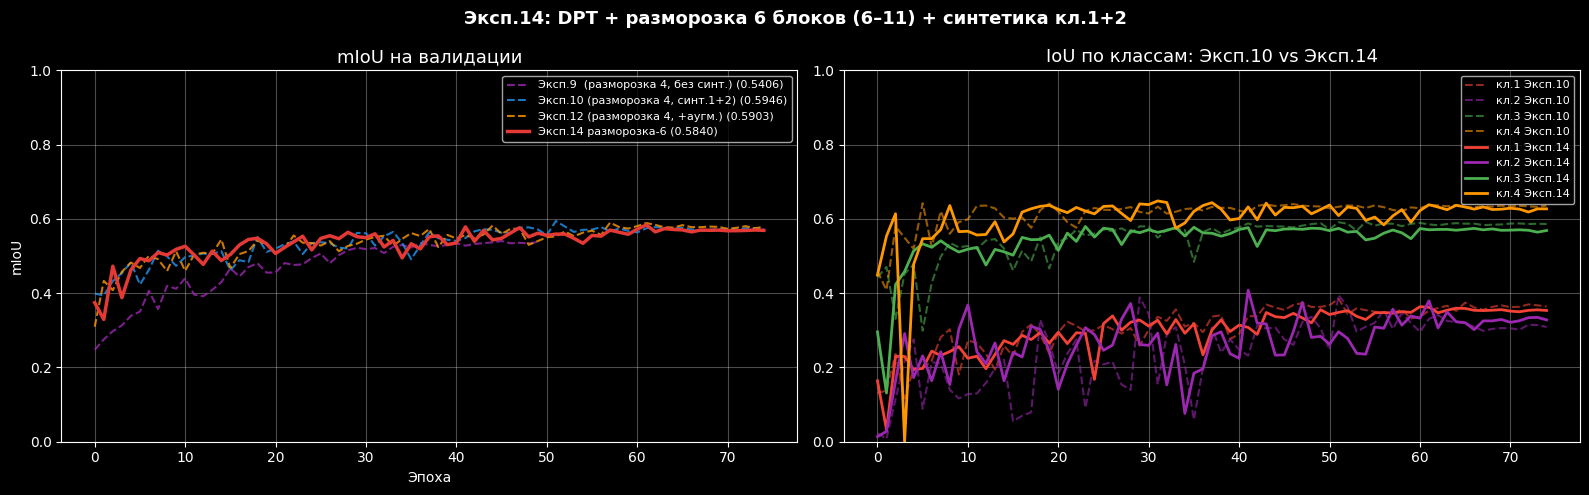

In [13]:
names = ['Фон', 'Дефект 1', 'Дефект 2', 'Дефект 3', 'Дефект 4']

m_14 = max(history_14['val_miou'])
e_14 = int(np.argmax(history_14['val_miou']))
i_14 = history_14['val_iou_per_class'][e_14]

results = {}
for name, fname in [
    ('Эксп.9  (разморозка 4, без синт.)', 'history_ft_dpt_v2.json'),
    ('Эксп.10 (разморозка 4, синт.1+2)', 'history_ft_dpt_synth_v2.json'),
    ('Эксп.12 (разморозка 4, +аугм.)',   'history_ft_dpt_aug.json'),
]:
    p = os.path.join(save_dir, fname)
    if os.path.exists(p):
        with open(p) as f:
            h = json.load(f)
        m = max(h['val_miou'])
        e = int(np.argmax(h['val_miou']))
        results[name] = {'miou': m, 'iou': h['val_iou_per_class'][e], 'hist': h}

print('ИТОГОВОЕ СРАВНЕНИЕ:')
for name, r in results.items():
    print(f'  {name:<40}: mIoU = {r["miou"]:.4f}')
print(f'  {"Эксп.14 (разморозка 6, синт.1+2)":<40}: mIoU = {m_14:.4f}')

ref10 = results.get('Эксп.10 (разморозка 4, синт.1+2)')
if ref10:
    print(f'\n  Прирост vs Эксп.10: {(m_14 - ref10["miou"])*100:+.1f}%')

print(f'\n  {"Класс":<14}', end='')
for name in results:
    print(f'{name[:12]:>14}', end='')
print(f'{"Эксп.14":>14}')
print('  ' + '-'*(14 + 14*len(results) + 14))
for c in range(NUM_CLASSES):
    print(f'  {names[c]:<14}', end='')
    for r in results.values():
        print(f'{r["iou"][c]:>14.4f}', end='')
    print(f'{i_14[c]:>14.4f}')

# Графики
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

palette = ['#9C27B0', '#2196F3', '#FF9800']
for (name, r), col in zip(results.items(), palette):
    axes[0].plot(r['hist']['val_miou'], color=col, lw=1.5,
                 label=f'{name} ({r["miou"]:.4f})', ls='--', alpha=0.8)
axes[0].plot(history_14['val_miou'], color='#E53935', lw=2.5,
             label=f'Эксп.14 разморозка-6 ({m_14:.4f})')
axes[0].set_title('mIoU на валидации', fontsize=13)
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('mIoU')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3); axes[0].set_ylim(0, 1)

cls_colors = {1:'#F44336', 2:'#9C27B0', 3:'#4CAF50', 4:'#FF9800'}
if ref10:
    for cls, col in cls_colors.items():
        axes[1].plot([h[cls] for h in ref10['hist']['val_iou_per_class']],
                     color=col, lw=1.5, ls='--', alpha=0.6, label=f'кл.{cls} Эксп.10')
for cls, col in cls_colors.items():
    axes[1].plot([h[cls] for h in history_14['val_iou_per_class']],
                 color=col, lw=2, label=f'кл.{cls} Эксп.14')
axes[1].set_title('IoU по классам: Эксп.10 vs Эксп.14', fontsize=13)
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3); axes[1].set_ylim(0, 1)

plt.suptitle('Эксп.14: DPT + разморозка 6 блоков (6–11) + синтетика кл.1+2',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 12. Сохранение

In [12]:
torch.save(model_14.state_dict(),
           os.path.join(save_dir, 'model_exp14_6blocks.pt'))
torch.save(dinov2.state_dict(),
           os.path.join(save_dir, 'dinov2_exp14_6blocks.pt'))
with open(os.path.join(save_dir, 'history_exp14_6blocks.json'), 'w') as f:
    json.dump(history_14, f)
print('Сохранено:')
print('  model_exp14_6blocks.pt      — голова DPT')
print('  dinov2_exp14_6blocks.pt     — backbone после fine-tuning')
print('  history_exp14_6blocks.json  — история обучения')
print(f'\nЛучший mIoU Эксп.14: {m_14:.4f}')
if ref10:
    print(f'Лучший mIoU Эксп.10: {ref10["miou"]:.4f}')
    print(f'Прирост:             {(m_14 - ref10["miou"])*100:+.1f}%')

Сохранено:
  model_exp14_6blocks.pt      — голова DPT
  dinov2_exp14_6blocks.pt     — backbone после fine-tuning
  history_exp14_6blocks.json  — история обучения

Лучший mIoU Эксп.14: 0.5840
Лучший mIoU Эксп.10: 0.5946
Прирост:             -1.1%
